<a href="https://colab.research.google.com/github/i-ganza007/Match_Backend/blob/main/DraftBreedRecogntion_EfficientBV0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

data_path = '/content/drive/MyDrive/Data'
print(f'Drive mounted. Data path set to: {data_path}')

Mounted at /content/drive
Drive mounted. Data path set to: /content/drive/MyDrive/Data


In [2]:
all_items = os.listdir(data_path)

# Filter to include only directories (representing classes) and exclude hidden files
classes = [item for item in all_items if os.path.isdir(os.path.join(data_path, item)) and not item.startswith('.')]

# Sort classes for consistent label mapping (important for class weights)
classes = sorted(classes)

print(f'Found {len(classes)} classes (sorted): {classes}')

# Check for any unexpected files in the root directory
non_dir_items = [item for item in all_items if not os.path.isdir(os.path.join(data_path, item))]
if non_dir_items:
    print(f'Warning: Found non-directory items in data path: {non_dir_items}')

Found 14 classes (sorted): ['brown_swiss_cow', 'dorper_sheep', 'duroc_pig', 'fresian_cow', 'girolando_cow', 'indigenous_ankole_cow', 'indigenous_goat', 'indigenous_pig', 'jersey_cow', 'landrace_pig', 'large_white_pig', 'merino_sheep', 'pietrain_pig', 'sahiwal_cow']


In [5]:
label_to_int = {label: idx for idx, label in enumerate(classes)}

data = []
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

for label in classes:
    class_path = os.path.join(data_path, label)
    for filename in os.listdir(class_path):
        if filename.lower().endswith(valid_extensions):
            filepath = os.path.join(class_path, filename)
            data.append({'filepath': filepath, 'label': label})

df = pd.DataFrame(data)
print(f'Total images found: {len(df)}')

# Stratified split
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f'Training samples: {len(train_df)}')
print(f'Validation samples: {len(val_df)}')
print(f'Testing samples: {len(test_df)}')

Total images found: 689
Training samples: 482
Validation samples: 103
Testing samples: 104


In [6]:
print('\nComputing class weights...')
y_train_int = train_df['label'].map(label_to_int).values
unique_int = np.unique(y_train_int)
weights = compute_class_weight('balanced', classes=unique_int, y=y_train_int)
class_weight_dict = dict(zip(unique_int, weights))

# 10x multiplier for rare breeds
rare_breeds = ['Sahiwal', 'Pietrain']   # add more if needed
for breed in rare_breeds:
    if breed in label_to_int:
        idx = label_to_int[breed]
        if idx in class_weight_dict:
            class_weight_dict[idx] *= 10.0
            print(f'Applied 10x weight multiplier to rare breed: {breed} (index {idx})')

print('Class weight dictionary:', class_weight_dict)

# Label-smoothed loss
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)
num_classes = len(classes)

# Load ResNet50 base
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.6)(x)          # high dropout as in your original
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

print(f'EfficientNetB0 initialized for {num_classes} classes.')
model.summary()


Computing class weights...
Class weight dictionary: {np.int64(0): np.float64(0.9060150375939849), np.int64(1): np.float64(0.8827838827838828), np.int64(2): np.float64(1.2751322751322751), np.int64(3): np.float64(0.8607142857142858), np.int64(4): np.float64(0.7325227963525835), np.int64(5): np.float64(0.8397212543554007), np.int64(6): np.float64(1.187192118226601), np.int64(7): np.float64(1.4968944099378882), np.int64(8): np.float64(1.0758928571428572), np.int64(9): np.float64(0.8827838827838828), np.int64(10): np.float64(1.0126050420168067), np.int64(11): np.float64(1.0126050420168067), np.int64(12): np.float64(1.1476190476190475), np.int64(13): np.float64(1.187192118226601)}
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 initialized for 14 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,067,505 (15.52 MB)

 Trainable params: 4,025,482 (15.36 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.8, 1.2],
    channel_shift_range=20.0,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    classes=classes
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    classes=classes
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    classes=classes
)

print(f'\nTotal training samples: {train_generator.n}')
print(f'Total validation samples: {val_generator.n}')
print(f'Total test samples: {test_generator.n}')

Found 482 validated image filenames belonging to 14 classes.
Found 103 validated image filenames belonging to 14 classes.
Found 104 validated image filenames belonging to 14 classes.

Total training samples: 482
Total validation samples: 103
Total test samples: 104


In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

# Phase A: Train only the head (base frozen)
base_model.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=['accuracy']
)

print('\n=== Phase A: Training head only ===')
history_phase_a = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print('\nPhase A complete.')

# Phase B: Fine-tuning
base_model.trainable = True

# Freeze all layers except the last 20 (you can adjust this number)
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # very low LR for fine-tuning
    loss=loss_fn,
    metrics=['accuracy']
)


=== Phase A: Training head only ===
Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 272s 16s/step - accuracy: 0.1079 - loss: 2.8035 - val_accuracy: 0.3204 - val_loss: 2.3500 - learning_rate: 0.0010
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.2946 - loss: 2.2962 - val_accuracy: 0.4369 - val_loss: 2.0322 - learning_rate: 0.0010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.4544 - loss: 1.9852 - val_accuracy: 0.5049 - val_loss: 1.8529 - learning_rate: 0.0010
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5498 - loss: 1.7684 - val_accuracy: 0.5534 - val_loss: 1.7203 - learning_rate: 0.0010
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5768 - loss: 1.6673 - val_accuracy: 0.5728 - val_loss: 1.6349 - learning_rate: 0.0010
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6162 - loss: 1.5627 - val_accuracy: 0.6117 - val_loss: 1.5767 - learning_rate: 0.0010
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy:

In [9]:
print('\n=== Phase B: Fine-tuning last 20 layers ===')
history_phase_b = model.fit(
    train_generator,
    epochs=50,
    initial_epoch=20,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print('\nEfficientNetB0 training completed.')


=== Phase B: Fine-tuning last 20 layers ===
Epoch 21/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.6929 - loss: 1.4210 - val_accuracy: 0.6990 - val_loss: 1.3742 - learning_rate: 1.0000e-05
Epoch 22/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6867 - loss: 1.4274 - val_accuracy: 0.6990 - val_loss: 1.3720 - learning_rate: 1.0000e-05
Epoch 23/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7033 - loss: 1.3715 - val_accuracy: 0.7087 - val_loss: 1.3731 - learning_rate: 1.0000e-05
Epoch 24/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7137 - loss: 1.3765 - val_accuracy: 0.7087 - val_loss: 1.3764 - learning_rate: 1.0000e-05
Epoch 25/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7116 - loss: 1.3408 - val_accuracy: 0.6990 - val_loss: 1.3794 - learning_rate: 1.0000e-05
Epoch 26/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 973ms/step - accuracy: 0.7145 - loss: 1.3761
Epoch 26: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
16/16 ━━━━━━━━━━


Evaluating the final model on the test set (single pass)...
4/4 ━━━━━━━━━━━━━━━━━━━━ 30s 10s/step - accuracy: 0.6827 - loss: 1.3463
Test Accuracy (single): 0.6827
Test Loss (single): 1.3463


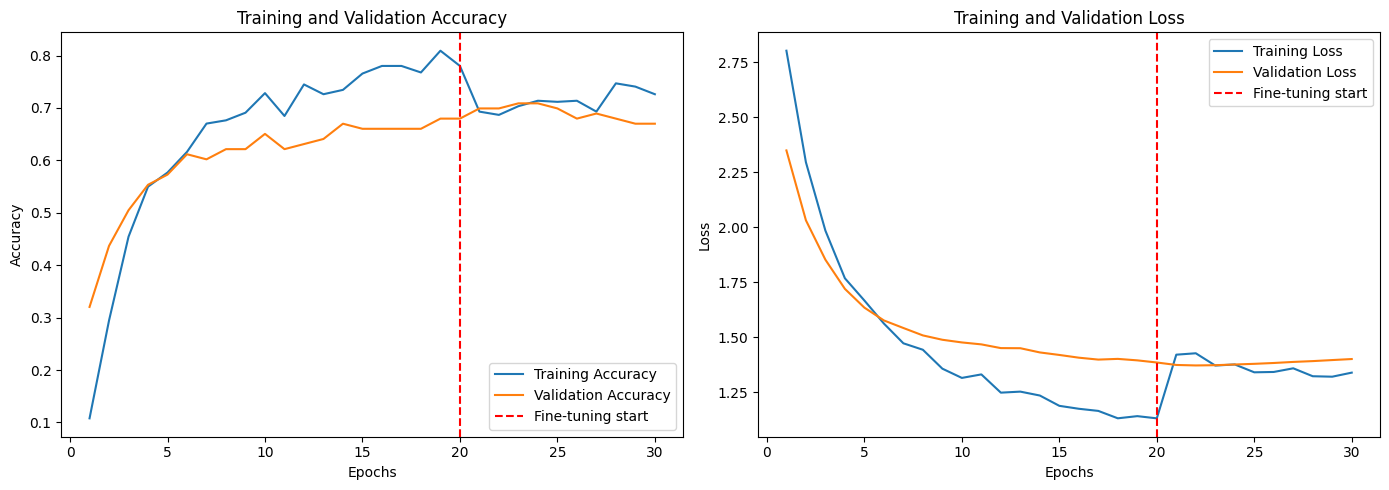

In [10]:
import matplotlib.pyplot as plt

print('\nEvaluating the final model on the test set (single pass)...')
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy (single): {test_acc:.4f}')
print(f'Test Loss (single): {test_loss:.4f}')

# Plot combined history
acc = history_phase_a.history['accuracy'] + history_phase_b.history['accuracy']
val_acc = history_phase_a.history['val_accuracy'] + history_phase_b.history['val_accuracy']
loss = history_phase_a.history['loss'] + history_phase_b.history['loss']
val_loss = history_phase_a.history['val_loss'] + history_phase_b.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=20, color='r', linestyle='--', label='Fine-tuning start')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=20, color='r', linestyle='--', label='Fine-tuning start')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Generating predictions for the test dataset (single pass)...
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step

Classification Report (single pass):
                       precision    recall  f1-score   support

      brown_swiss_cow       0.83      0.62      0.71         8
         dorper_sheep       1.00      0.78      0.88         9
            duroc_pig       0.80      0.80      0.80         5
          fresian_cow       0.80      0.44      0.57         9
        girolando_cow       0.73      0.80      0.76        10
indigenous_ankole_cow       0.89      0.89      0.89         9
      indigenous_goat       0.86      1.00      0.92         6
       indigenous_pig       0.43      0.60      0.50         5
           jersey_cow       0.50      0.57      0.53         7
         landrace_pig       0.67      0.22      0.33         9
      large_white_pig       0.67      0.86      0.75         7
         merino_sheep       0.73      1.00      0.84         8
         pietrain_pig       0.50      0.50  

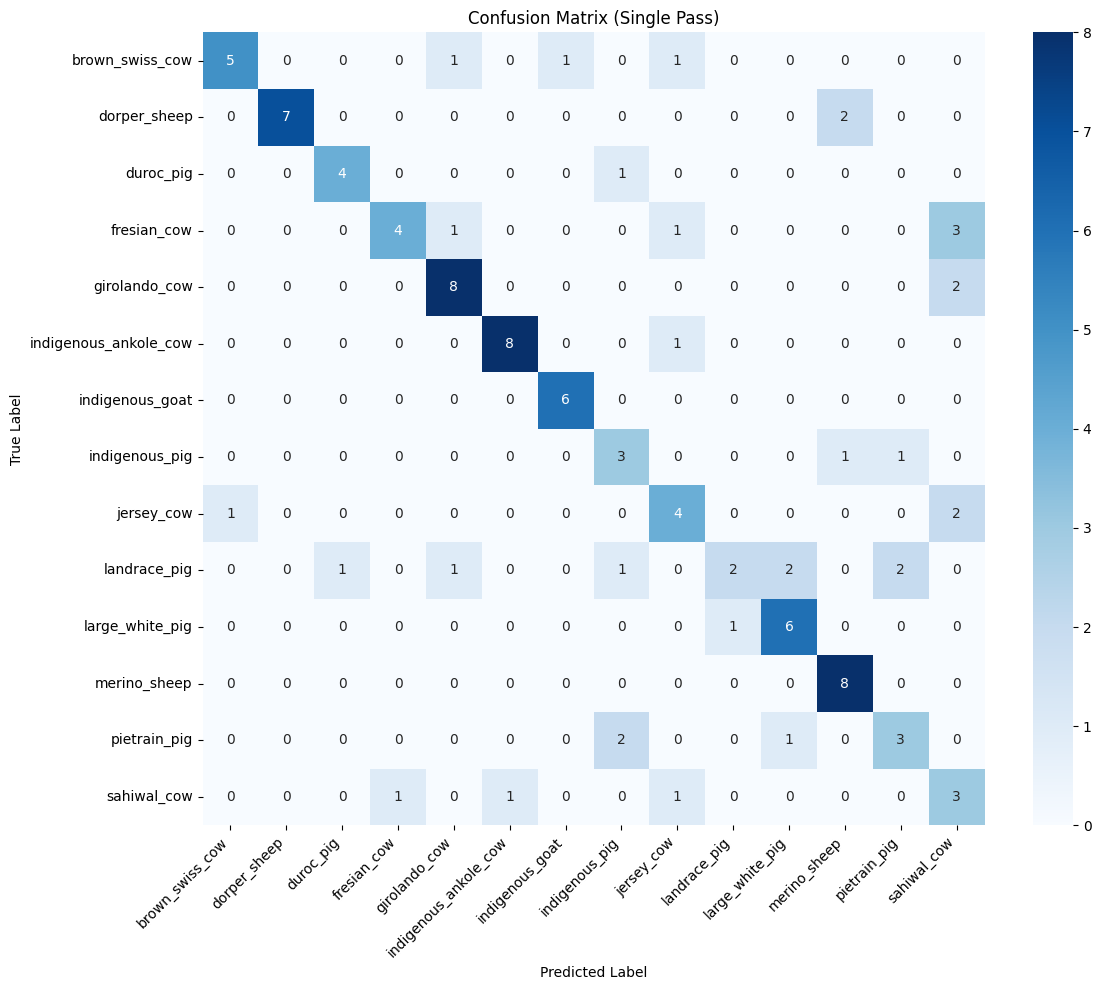


Performing Test-Time Augmentation (TTA) with 5 augmented versions...
Found 104 validated image filenames belonging to 14 classes.
TTA pass 1/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 830ms/step
TTA pass 2/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
TTA pass 3/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 840ms/step
TTA pass 4/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
TTA pass 5/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 818ms/step

Classification Report (TTA):
                       precision    recall  f1-score   support

      brown_swiss_cow       0.67      0.50      0.57         8
         dorper_sheep       1.00      0.78      0.88         9
            duroc_pig       0.80      0.80      0.80         5
          fresian_cow       0.67      0.44      0.53         9
        girolando_cow       0.78      0.70      0.74        10
indigenous_ankole_cow       0.89      0.89      0.89         9
      indigenous_goat       0.86      1.00      0.92         6
       indigenous_pig       0.43      0.60      0.50         5
  

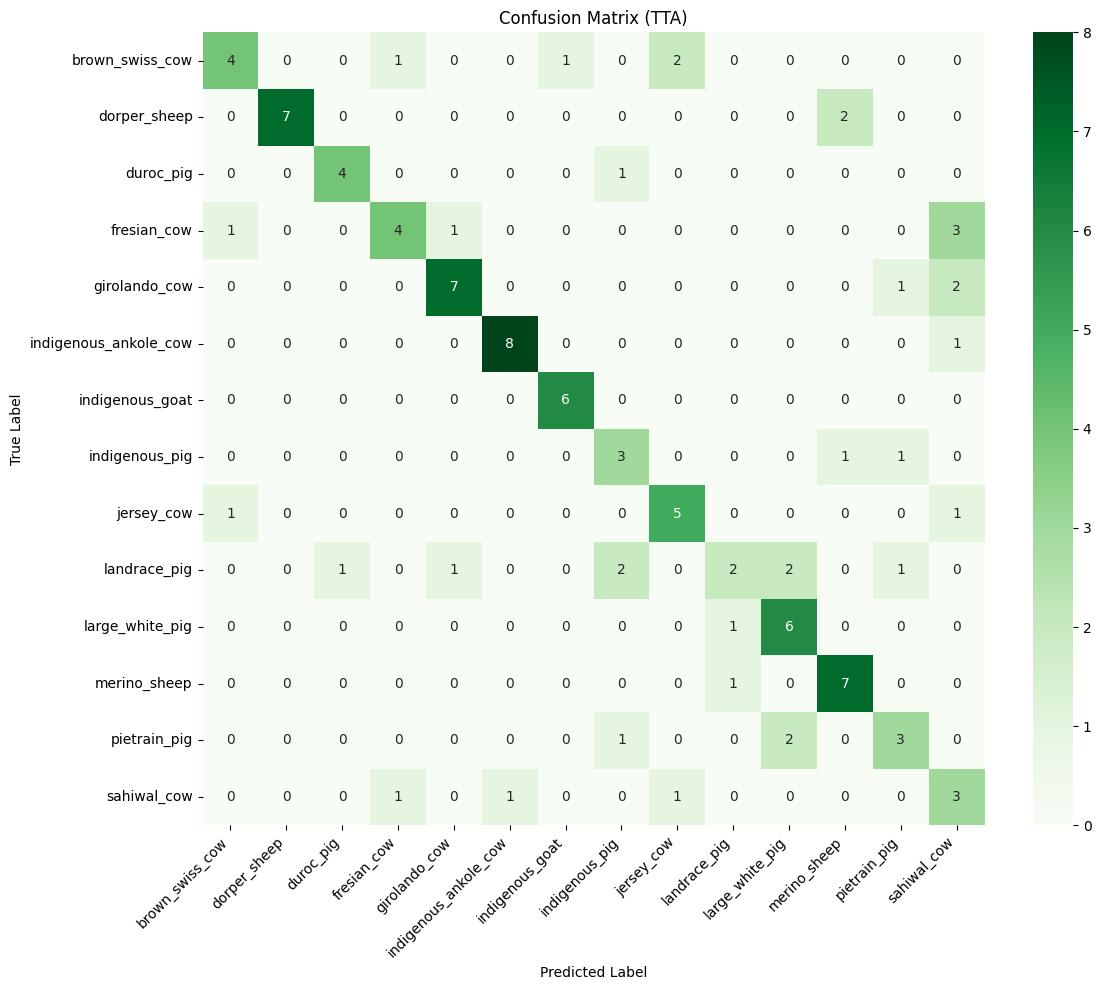

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print('Generating predictions for the test dataset (single pass)...')
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print('\nClassification Report (single pass):')
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix (original)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Single Pass)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Test-Time Augmentation (TTA) for better generalization on rare classes
print('\nPerforming Test-Time Augmentation (TTA) with 5 augmented versions...')
tta_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    shear_range=5.0,
    channel_shift_range=10.0,
    fill_mode='nearest'
)

tta_generator = tta_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    classes=classes
)

n_tta = 5
tta_preds = []
for i in range(n_tta):
    print(f'TTA pass {i+1}/{n_tta}...')
    tta_generator.reset()
    pred = model.predict(tta_generator, verbose=1)
    tta_preds.append(pred)

avg_tta_probs = np.mean(tta_preds, axis=0)
y_pred_tta = np.argmax(avg_tta_probs, axis=1)

print('\nClassification Report (TTA):')
print(classification_report(y_true, y_pred_tta, target_names=class_names))

cm_tta = confusion_matrix(y_true, y_pred_tta)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (TTA)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()